# K Nearest Neighbors

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
sns.set_style('darkgrid')

## Importing the Dataset

In [2]:
df = pd.read_csv("../../Datasets/bdiag.csv")

# Drop the 'id' column as it's not needed for analysis
df = df.drop('id', axis=1)

# Encode diagnosis: M (Malignant) = 1, B (Benign) = 0
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nDiagnosis distribution:")
print(df['diagnosis'].value_counts())

df_original = df.copy()

Dataset loaded successfully!
Shape: (569, 32)

Diagnosis distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [3]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

## Basic Data Representation

In [5]:
# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*80 + "\n")

# Display last few rows
print("Last 5 rows of the dataset:")
print(df.tail())
print("\n" + "="*80 + "\n")

# Dataset information
print("Dataset Information:")
print(df.info())
print("\n" + "="*80 + "\n")

# Statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*80 + "\n")

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*80 + "\n")

# Target distribution
print("Target Distribution:")
print(df['diagnosis'].value_counts())
print("\nTarget Distribution (%):")
print(df['diagnosis'].value_counts(normalize=True) * 100)

First 5 rows of the dataset:
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  texture_worst  perimeter_worst  area_worst  \
0         0.2419  ...   

## Exploratory Data Analysis (EDA)

### Correlation Analysis

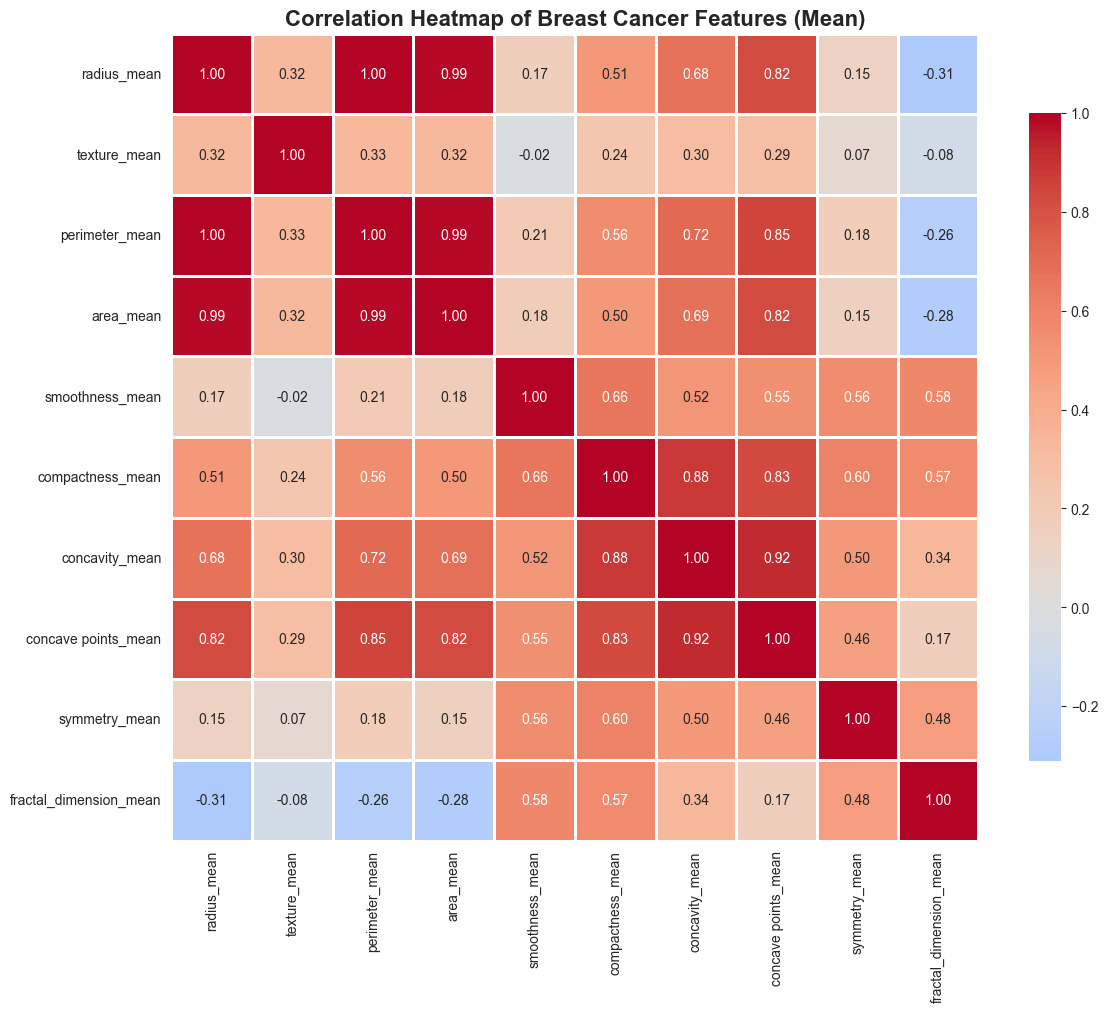

In [6]:
# Get numerical feature columns (excluding diagnosis and target)
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in numerical_features:
    numerical_features.remove('target')

# Correlation matrix for numerical features (subset for visualization)
# We'll show correlations for the first 10 mean features
mean_features = [col for col in numerical_features if 'mean' in col][:10]

plt.figure(figsize=(12, 10))
correlation_matrix = df[mean_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Heatmap of Breast Cancer Features (Mean)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Pairplot Analysis

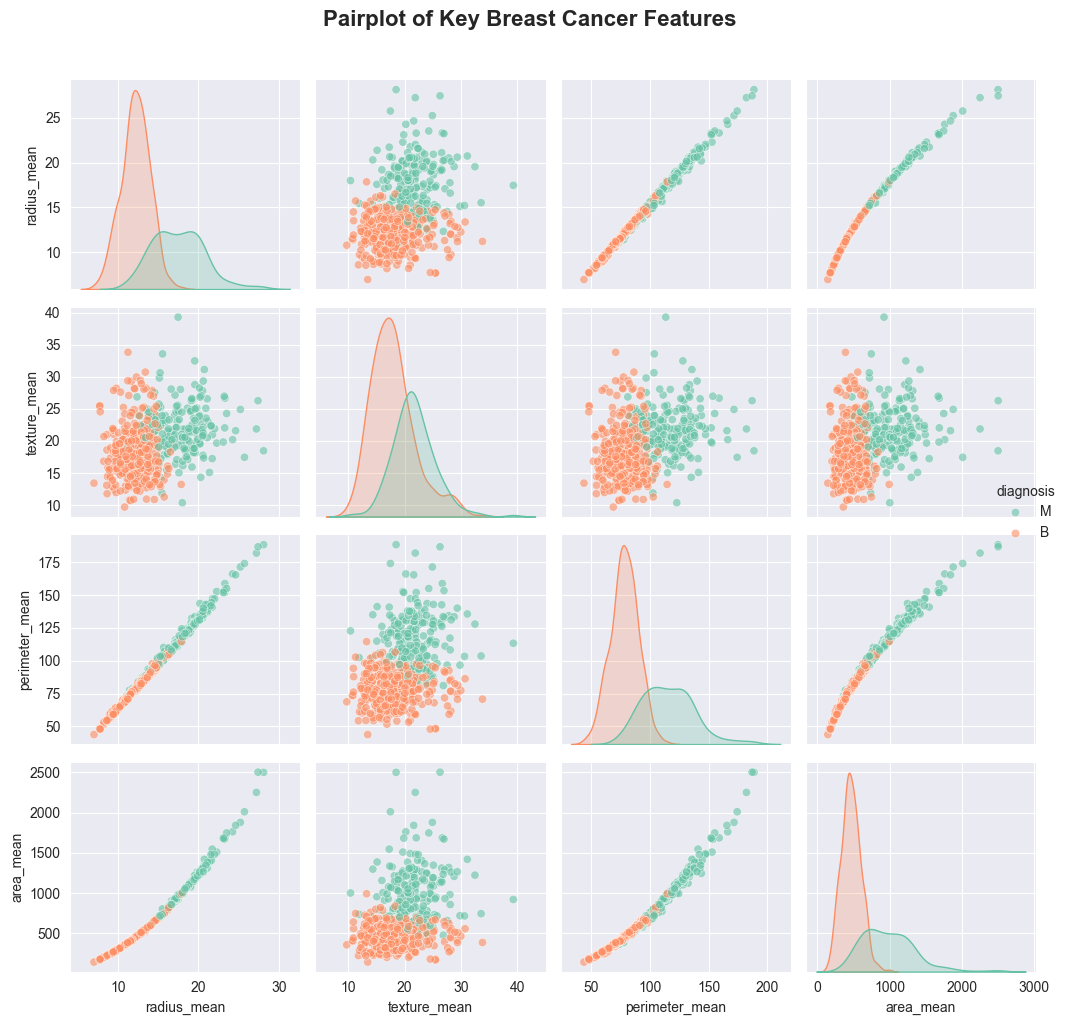

In [7]:
# Pairplot to visualize relationships between key features
# Select a few key mean features for visualization
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']
sns.pairplot(df[key_features], hue='diagnosis', diag_kind='kde', palette='Set2',
             plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Pairplot of Key Breast Cancer Features', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Distribution Analysis

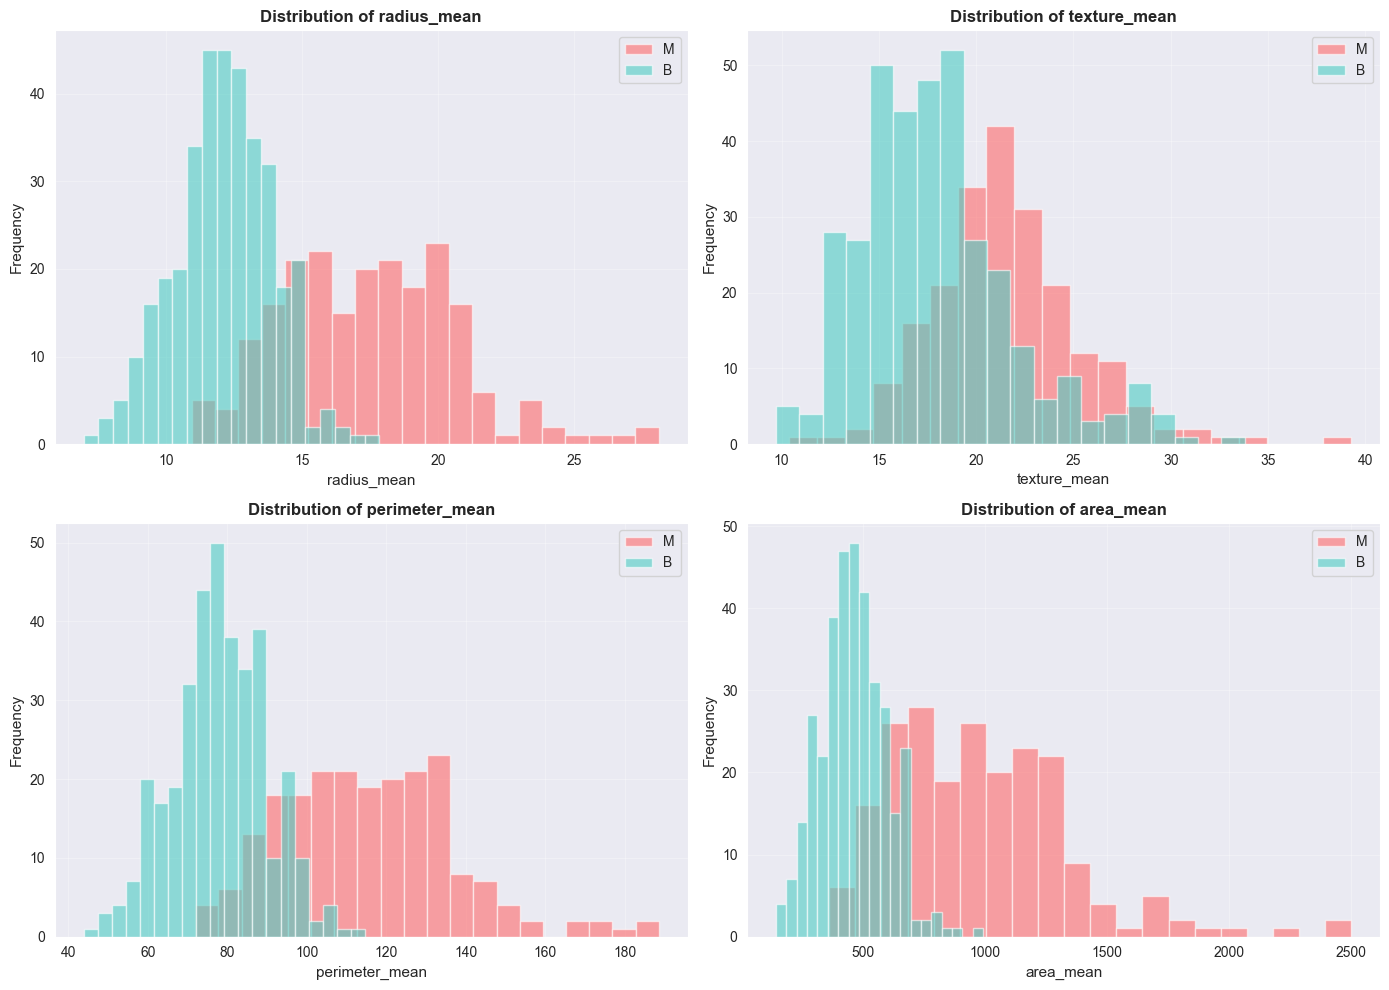

In [8]:
# Distribution plots for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#FF6B6B', '#4ECDC4']
key_plot_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

for idx, col in enumerate(key_plot_features):
    ax = axes[idx // 2, idx % 2]
    for i, diagnosis in enumerate(df['diagnosis'].unique()):
        data = df[df['diagnosis'] == diagnosis][col]
        ax.hist(data, alpha=0.6, label=diagnosis, bins=20, color=colors[i])
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Box Plot Analysis

/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_27864/3917844355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, ax=ax, palette='Set2')
/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_27864/3917844355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, ax=ax, palette='Set2')
/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_27864/3917844355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col, ax=ax, palette='Set2')
/

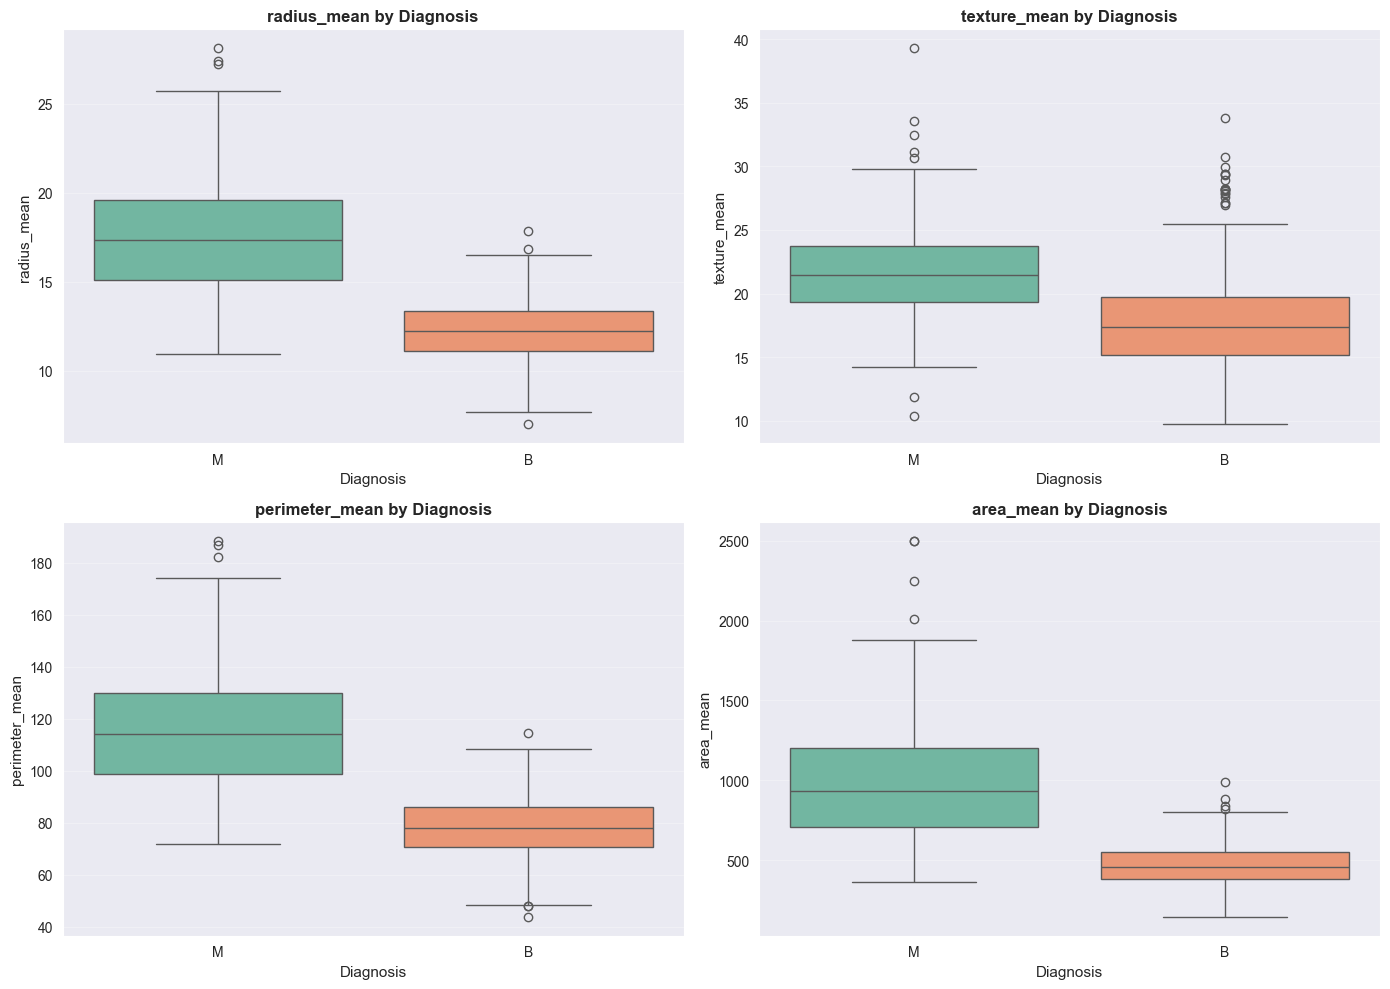

In [9]:
# Box plots to identify outliers and compare distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
key_plot_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

for idx, col in enumerate(key_plot_features):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df, x='diagnosis', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by Diagnosis', fontsize=12, fontweight='bold')
    ax.set_xlabel('Diagnosis', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Second Degree Treatment

### Outlier Detection and Removal Groupwise

In [10]:
# Outlier Detection and Removal using Groupwise IQR Method
# This computes IQR bounds per diagnosis group instead of globally

df_grouped_clean = df_original.copy()

# Get numerical features for outlier detection (excluding target)
features_for_outlier_detection = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in features_for_outlier_detection:
    features_for_outlier_detection.remove('target')

print(f"Original dataset shape: {df_original.shape}")
print(f"Number of rows before groupwise outlier removal: {len(df_original)}")


def remove_outliers_groupwise(data, features, group_col='diagnosis'):
    """Remove outliers using IQR method computed within each group."""
    mask = pd.Series(True, index=data.index)

    for col in features:
        for group in data[group_col].unique():
            group_mask = data[group_col] == group
            group_data = data.loc[group_mask, col]

            Q1 = group_data.quantile(0.25)
            Q3 = group_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Mark rows that are outliers within this group
            outlier_mask = group_mask & ((data[col] < lower_bound) | (data[col] > upper_bound))
            mask = mask & ~outlier_mask

            n_outliers = outlier_mask.sum()
            if n_outliers > 0:
                print(f"  {col} | {group}: {n_outliers} outlier(s) removed "
                      f"(bounds: [{lower_bound:.4f}, {upper_bound:.4f}])")

    return data[mask]


print("\nOutliers detected per feature and diagnosis group:")
print("-" * 70)
df_grouped_clean = remove_outliers_groupwise(df_original, features_for_outlier_detection, group_col='diagnosis')

print("\n" + "=" * 80)
print(f"\nCleaned dataset shape (groupwise): {df_grouped_clean.shape}")
print(f"Number of rows after groupwise outlier removal: {len(df_grouped_clean)}")
print(f"Number of rows removed: {len(df_original) - len(df_grouped_clean)}")

# Reset index
df_grouped_clean = df_grouped_clean.reset_index(drop=True)

print("\n" + "=" * 80)
print("\nGroupwise Cleaned Dataset - First 10 rows:")
df_grouped_clean.head(10)

Original dataset shape: (569, 32)
Number of rows before groupwise outlier removal: 569

Outliers detected per feature and diagnosis group:
----------------------------------------------------------------------
  radius_mean | M: 3 outlier(s) removed (bounds: [8.3025, 26.3625])
  radius_mean | B: 3 outlier(s) removed (bounds: [7.6450, 16.8050])
  texture_mean | M: 7 outlier(s) removed (bounds: [12.6713, 30.4213])
  texture_mean | B: 18 outlier(s) removed (bounds: [8.2350, 26.6750])
  perimeter_mean | M: 3 outlier(s) removed (bounds: [51.9750, 176.6950])
  perimeter_mean | B: 4 outlier(s) removed (bounds: [48.0250, 108.9450])
  area_mean | M: 4 outlier(s) removed (bounds: [-42.3750, 1951.4250])
  area_mean | B: 4 outlier(s) removed (bounds: [118.8500, 810.4500])
  smoothness_mean | M: 3 outlier(s) removed (bounds: [0.0686, 0.1363])
  smoothness_mean | B: 4 outlier(s) removed (bounds: [0.0566, 0.1272])
  compactness_mean | M: 8 outlier(s) removed (bounds: [0.0154, 0.2666])
  compactness_m

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,1
1,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,1
2,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.2,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,1
3,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,23.75,103.4,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,1
4,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,27.66,153.2,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,1
5,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,28.14,110.6,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,1
6,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,30.73,106.2,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,1
7,M,16.02,23.24,102.70,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,...,33.88,123.8,1150.0,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452,1
8,M,15.78,17.89,103.60,781.0,0.09710,0.12920,0.09954,0.06606,0.1842,...,27.28,136.5,1299.0,0.1396,0.5609,0.3965,0.18100,0.3792,0.10480,1
9,M,15.85,23.95,103.70,782.7,0.08401,0.10020,0.09938,0.05364,0.1847,...,27.66,112.0,876.5,0.1131,0.1924,0.2322,0.11190,0.2809,0.06287,1


/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_27864/3882790888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grouped_clean, x='diagnosis', y=col, ax=ax, palette='Set2')
/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_27864/3882790888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grouped_clean, x='diagnosis', y=col, ax=ax, palette='Set2')
/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_27864/3882790888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grouped_clean, x='d

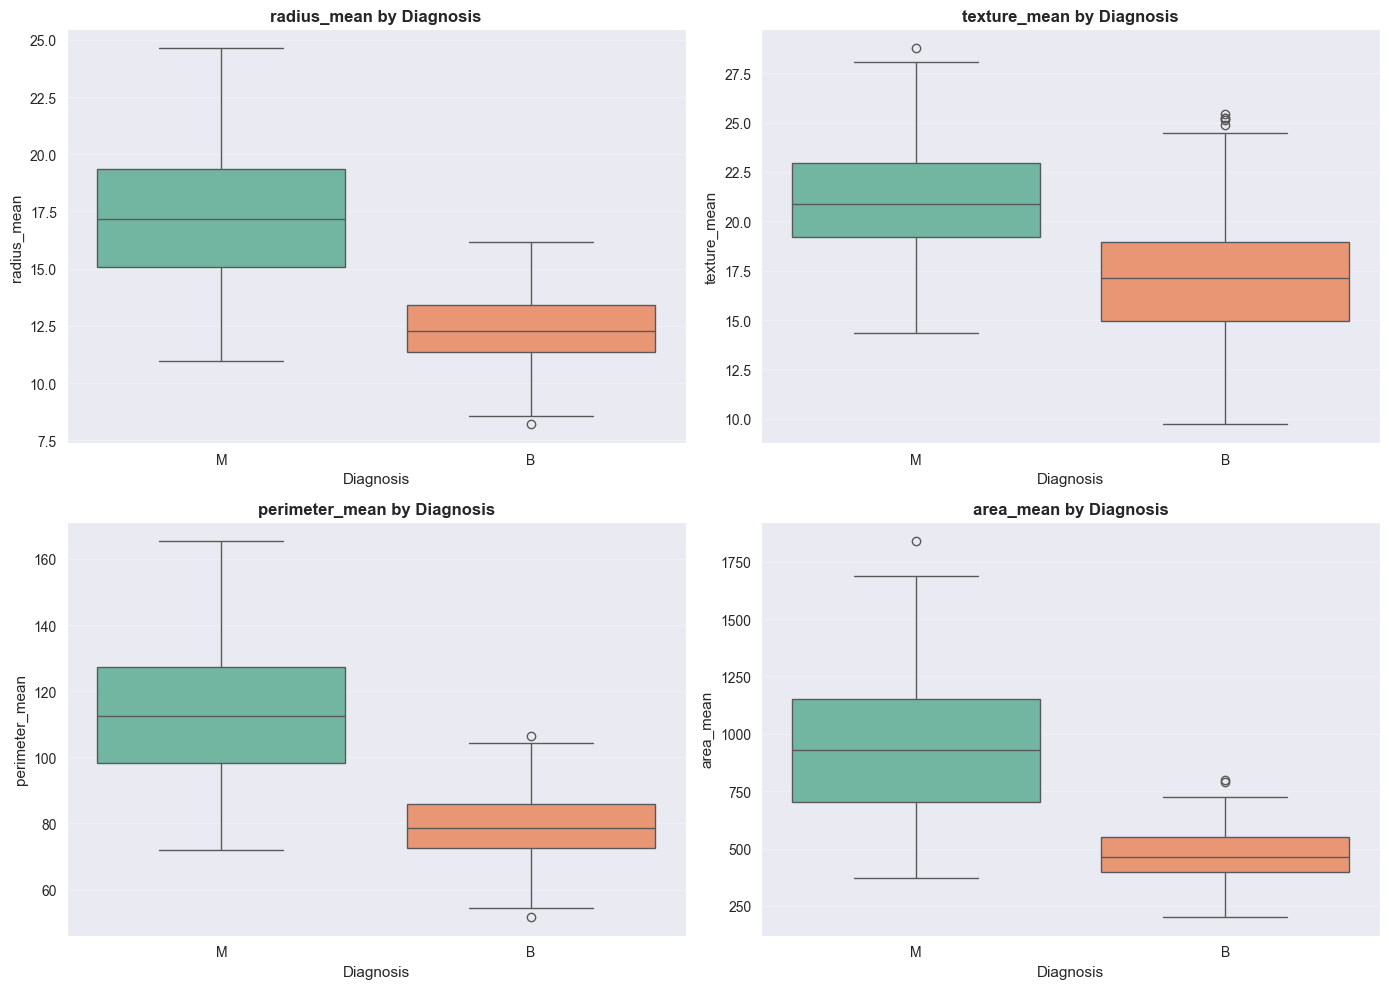

In [11]:
# Box plots to identify outliers and compare distributions after cleaning
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
key_plot_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

for idx, col in enumerate(key_plot_features):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df_grouped_clean, x='diagnosis', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by Diagnosis', fontsize=12, fontweight='bold')
    ax.set_xlabel('Diagnosis', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Training the Model

In [12]:
# Apply StandardScaler to the feature data
# Get all numerical features excluding diagnosis and target
feature_columns = df_grouped_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in feature_columns:
    feature_columns.remove('target')

X = df_grouped_clean[feature_columns].values
y = df_grouped_clean['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a scaled DataFrame for reference
df_scaled = pd.DataFrame(X_scaled, columns=feature_columns)
df_scaled['target'] = y
df_scaled['diagnosis'] = df_grouped_clean['diagnosis'].values

print("StandardScaler applied successfully!")

StandardScaler applied successfully!


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("KNN Model Results on Scaled Data (Second Degree Treatment)")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'])}")

KNN Model Results on Scaled Data (Second Degree Treatment)

Accuracy: 95.08%

Confusion Matrix:
[[82  0]
 [ 6 34]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      1.00      0.96        82
   Malignant       1.00      0.85      0.92        40

    accuracy                           0.95       122
   macro avg       0.97      0.93      0.94       122
weighted avg       0.95      0.95      0.95       122



## Third Degree Treatment

### Outlier Detection and Removal

In [14]:
print(f"Dataset shape after second degree treatment: {df_grouped_clean.shape}")
print(f"Number of rows before third degree outlier removal: {len(df_grouped_clean)}")


def remove_outliers_third_degree(data, features, group_col='diagnosis', multiplier=3.0):
    """Remove outliers using IQR method with a 3x multiplier (third degree) computed within each group."""
    mask = pd.Series(True, index=data.index)

    for col in features:
        for group in data[group_col].unique():
            group_mask = data[group_col] == group
            group_data = data.loc[group_mask, col]

            Q1 = group_data.quantile(0.05)
            Q3 = group_data.quantile(0.95)

            lower_bound = Q1
            upper_bound = Q3

            # Mark rows that are outliers within this group
            outlier_mask = group_mask & ((data[col] < lower_bound) | (data[col] > upper_bound))
            mask = mask & ~outlier_mask

            n_outliers = outlier_mask.sum()
            if n_outliers > 0:
                print(f"  {col} | {group}: {n_outliers} outlier(s) removed "
                      f"(bounds: [{lower_bound:.4f}, {upper_bound:.4f}])")

    return data[mask]


print("\nOutliers detected per feature and diagnosis group (3rd degree):")
print("-" * 70)
df_third_degree_clean = remove_outliers_third_degree(df_original, features_for_outlier_detection, group_col='diagnosis')

print("\n" + "=" * 80)
print(f"\nCleaned dataset shape (third degree): {df_third_degree_clean.shape}")
print(f"Number of rows after third degree outlier removal: {len(df_third_degree_clean)}")
print(f"Number of rows removed: {len(df_grouped_clean) - len(df_third_degree_clean)}")

# Reset index
df_third_degree_clean = df_third_degree_clean.reset_index(drop=True)

print("\n" + "=" * 80)
print("\nThird Degree Cleaned Dataset - First 10 rows:")
df_third_degree_clean.head(10)

Dataset shape after second degree treatment: (405, 32)
Number of rows before third degree outlier removal: 405

Outliers detected per feature and diagnosis group (3rd degree):
----------------------------------------------------------------------
  radius_mean | M: 22 outlier(s) removed (bounds: [12.8030, 23.1440])
  radius_mean | B: 36 outlier(s) removed (bounds: [9.0394, 14.9260])
  texture_mean | M: 22 outlier(s) removed (bounds: [16.0555, 27.9090])
  texture_mean | B: 36 outlier(s) removed (bounds: [12.8380, 25.7900])
  perimeter_mean | M: 22 outlier(s) removed (bounds: [84.6795, 152.4150])
  perimeter_mean | B: 36 outlier(s) removed (bounds: [58.9660, 96.5660])
  area_mean | M: 22 outlier(s) removed (bounds: [504.9050, 1675.4000])
  area_mean | B: 36 outlier(s) removed (bounds: [248.2200, 681.6200])
  smoothness_mean | M: 22 outlier(s) removed (bounds: [0.0840, 0.1236])
  smoothness_mean | B: 35 outlier(s) removed (bounds: [0.0735, 0.1150])
  compactness_mean | M: 22 outlier(s) re

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,1
1,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,1
2,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,1
3,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,1
4,M,15.78,17.89,103.60,781.0,0.09710,0.12920,0.09954,0.06606,0.1842,...,27.28,136.50,1299.0,0.1396,0.5609,0.3965,0.18100,0.3792,0.10480,1
5,M,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.05259,0.1586,...,30.88,123.40,1138.0,0.1464,0.1871,0.2914,0.16090,0.3029,0.08216,1
6,M,16.13,20.68,108.10,798.8,0.11700,0.20220,0.17220,0.10280,0.2164,...,31.48,136.80,1315.0,0.1789,0.4233,0.4784,0.20730,0.3706,0.11420,1
7,M,19.81,22.15,130.00,1260.0,0.09831,0.10270,0.14790,0.09498,0.1582,...,30.88,186.80,2398.0,0.1512,0.3150,0.5372,0.23880,0.2768,0.07615,1
8,B,13.54,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.04781,0.1885,...,19.26,99.70,711.2,0.1440,0.1773,0.2390,0.12880,0.2977,0.07259,0
9,B,13.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,...,20.49,96.09,630.5,0.1312,0.2776,0.1890,0.07283,0.3184,0.08183,0


### Training the Model

In [15]:
# Apply StandardScaler to the feature data
X = df_third_degree_clean[feature_columns].values
y = df_third_degree_clean['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a scaled DataFrame for reference
df_scaled = pd.DataFrame(X_scaled, columns=feature_columns)
df_scaled['target'] = y
df_scaled['diagnosis'] = df_third_degree_clean['diagnosis'].values

print("StandardScaler applied successfully!")

StandardScaler applied successfully!


In [16]:
# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("KNN Model Results on Scaled Data (Third Degree Treatment)")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'])}")

KNN Model Results on Scaled Data (Third Degree Treatment)

Accuracy: 98.21%

Confusion Matrix:
[[36  0]
 [ 1 19]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        36
   Malignant       1.00      0.95      0.97        20

    accuracy                           0.98        56
   macro avg       0.99      0.97      0.98        56
weighted avg       0.98      0.98      0.98        56



## 2D Visualization with Decision Boundary


Confusion Matrix (k=5):
[[102   6]
 [ 14  49]]


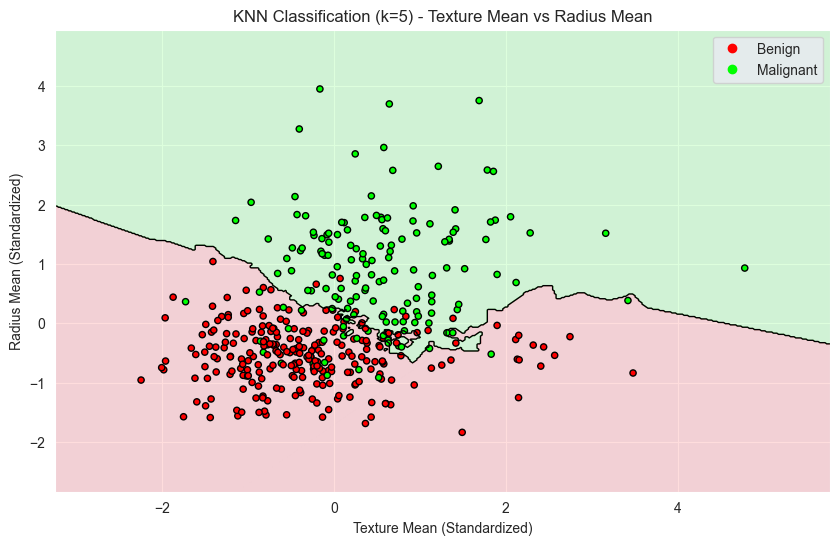


Confusion Matrix (k=15):
[[105   3]
 [ 13  50]]


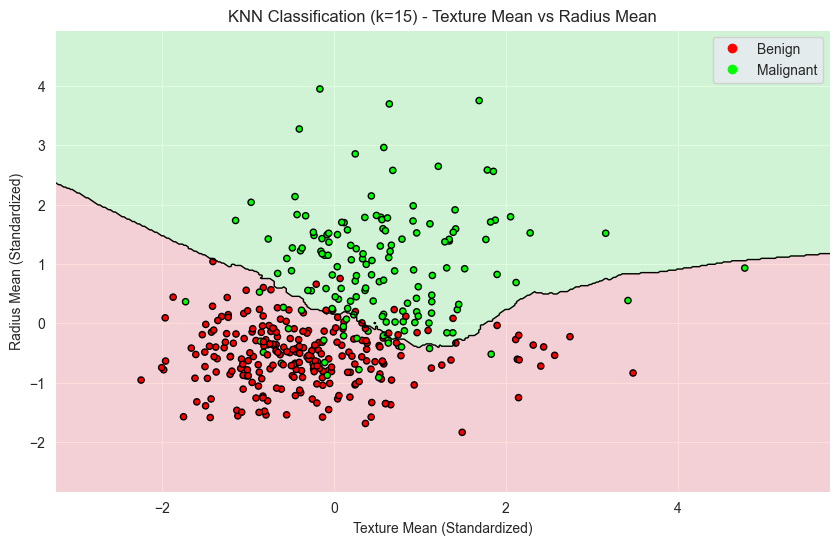

In [17]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(k_value):
    # Select only two features for visualization
    X_vis = df[['texture_mean', 'radius_mean']].values
    y_vis = df['target'].values

    # Split data
    X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_vis, test_size=0.3, random_state=42)

    # Scale the data
    scaler_vis = StandardScaler()
    X_train_vis = scaler_vis.fit_transform(X_train_vis)
    X_test_vis = scaler_vis.transform(X_test_vis)

    # Train KNN
    knn_vis = KNeighborsClassifier(n_neighbors=k_value)
    knn_vis.fit(X_train_vis, y_train_vis)

    # Predict and print confusion matrix
    y_pred_vis = knn_vis.predict(X_test_vis)
    print(f"\nConfusion Matrix (k={k_value}):")
    print(confusion_matrix(y_test_vis, y_pred_vis))

    # Create meshgrid for decision boundary
    h = 0.02  # step size in the mesh
    x_min, x_max = X_train_vis[:, 0].min() - 1, X_train_vis[:, 0].max() + 1
    y_min, y_max = X_train_vis[:, 1].min() - 1, X_train_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for each point in meshgrid
    Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(10, 6))
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)

    # Draw the boundary line
    plt.contour(xx, yy, Z, colors='black', linewidths=1, levels=[0.5])

    # Plot training points
    scatter = plt.scatter(X_train_vis[:, 0], X_train_vis[:, 1], c=y_train_vis, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f"KNN Classification (k={k_value}) - Texture Mean vs Radius Mean")
    plt.xlabel("Texture Mean (Standardized)")
    plt.ylabel("Radius Mean (Standardized)")
    plt.legend(handles=scatter.legend_elements()[0], labels=['Benign', 'Malignant'])
    plt.show()

# Plot for k=5
plot_decision_boundary(5)

# Plot for k=15
plot_decision_boundary(15)